<a href="https://colab.research.google.com/github/Shahul187/f1-eda-2021/blob/main/Chapter_2_Qualifying_vs_RaceDay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install fastf1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 115.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.0 MB/s eta 0:00:00


In [2]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# Create cache folder if it doesn't exist, then enable it
os.makedirs('/tmp/fastf1_cache', exist_ok=True)
fastf1.Cache.enable_cache('/tmp/fastf1_cache')

In [3]:
ver_data = []
ham_data = []
race_names = []

for round_num in range(1, 23):
    try:
        session = fastf1.get_session(2021, round_num, 'R')
        session.load(telemetry=False, weather=False, messages=False)
        results = session.results
        quali = fastf1.get_session(2021, round_num, 'Q')
        quali.load(telemetry=False, weather=False, messages=False)
        quali_results = quali.results

        race_names.append(session.event['EventName'].replace('Grand Prix', 'GP'))

        for drv, store in [('VER', ver_data), ('HAM', ham_data)]:
            r_row = results[results['Abbreviation'] == drv]
            q_row = quali_results[quali_results['Abbreviation'] == drv]

            race_pos = int(r_row['Position'].values[0]) if not r_row.empty else None
            grid_pos = int(r_row['GridPosition'].values[0]) if not r_row.empty else None

            store.append({
                'race': race_names[-1],
                'grid': grid_pos,
                'finish': race_pos,
                'gained': (grid_pos - race_pos) if grid_pos and race_pos else 0
            })

    except Exception as e:
        print(f"Round {round_num} skipped: {e}")

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_d

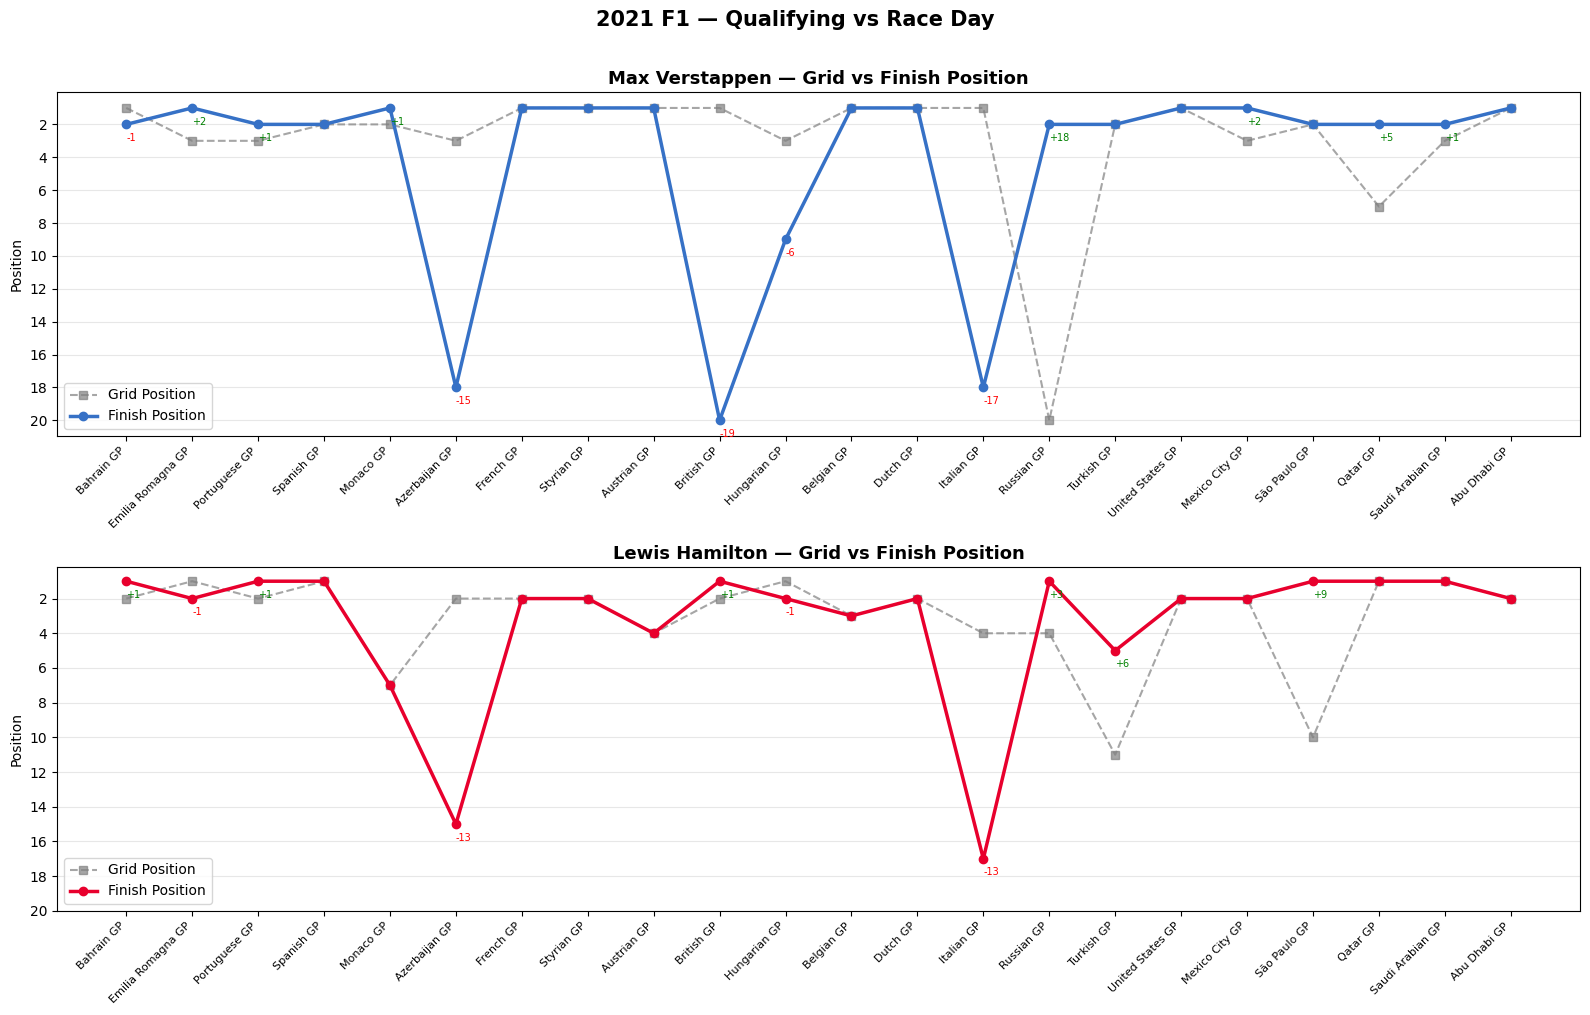

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for ax, data, name, color in zip(
    axes,
    [ver_data, ham_data],
    ['Max Verstappen', 'Lewis Hamilton'],
    ['#3671C6', '#E8002D']
):
    df = pd.DataFrame(data).dropna()
    races = df['race']
    x = range(len(races))

    ax.plot(x, df['grid'], marker='s', linestyle='--',
            color='gray', linewidth=1.5, label='Grid Position', alpha=0.7)
    ax.plot(x, df['finish'], marker='o', linestyle='-',
            color=color, linewidth=2.5, label='Finish Position')


    for i, row in df.iterrows():
        if row['gained'] > 0:
            ax.annotate(f"+{int(row['gained'])}",
                       (i, row['finish']), textcoords="offset points",
                       xytext=(0, -12), fontsize=7, color='green')
        elif row['gained'] < 0:
            ax.annotate(f"{int(row['gained'])}",
                       (i, row['finish']), textcoords="offset points",
                       xytext=(0, -12), fontsize=7, color='red')

    ax.invert_yaxis()  # P1 at top
    ax.set_title(f'{name} — Grid vs Finish Position', fontsize=13, fontweight='bold')
    ax.set_xticks(list(x))
    ax.set_xticklabels(list(races), rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Position')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('2021 F1 — Qualifying vs Race Day',
             fontsize=15, fontweight='bold', y=1.01)
axes[0].set_yticks([2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
axes[1].set_yticks([2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
plt.tight_layout()
plt.show()

# **Chapter 2 — Qualifying vs Race Day**

The qualifying pace and race pace told two different stories. Verstappen and Hamilton were closely matched over a single lap, but the grid position was not the only deciding factor for their victory. There are other factors which happen between lights out and the chequered flag such as the team's strategy, tyre management and racecraft rather than grid position alone.

Hamilton, known for his ability to manage races from the front, was at his most dangerous when starting from pole.

Verstappen, on the other hand, showed a remarkable ability to recover positions when grid penalties or incidents dropped him down the order.